<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS05/JS05_Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas 1 — Klasifikasi Suara


## Persiapan

Jika pustaka belum tersedia, hapus tanda `#` pada baris `%pip` lalu jalankan.

In [4]:
# %pip install numpy pandas scikit-learn matplotlib seaborn

In [5]:
get_ipython().run_line_magic('matplotlib', 'inline')
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 110})
pd.set_option('display.max_columns', 25)
pd.set_option('display.precision', 4)

print('Versi pustaka:')
display(pd.Series({
    'Python': platform.python_version(), 'NumPy': np.__version__,
    'pandas': pd.__version__, 'scikit-learn': sklearn.__version__,
    'Matplotlib': matplotlib.__version__, 'seaborn': sns.__version__
}, name='Versi').to_frame())

Versi pustaka:


,Versi
Python,3.13.15
NumPy,2.1.3
pandas,2.2.3
scikit-learn,1.6.1
Matplotlib,3.10.0
seaborn,0.13.2


### Membaca dataset

Ubah `DATA_DIR` jika dataset disimpan di folder lain.

In [6]:
DATA_DIR = Path('.')  # Ganti bila perlu, misalnya Path('/content')

def data_path(nama):
    kandidat = [
        DATA_DIR / nama, DATA_DIR / 'data' / nama,
        Path('/content') / nama, Path.home() / 'Downloads' / nama
    ]
    for lokasi in kandidat:
        if lokasi.is_file():
            return lokasi
    raise FileNotFoundError(
        f'{nama} tidak ditemukan. Letakkan CSV di folder notebook/data/ '
        'atau ubah DATA_DIR.'
    )

for nama in ['voice.csv']:
    lokasi = data_path(nama)
    print(f'{nama}: ditemukan ({lokasi.stat().st_size:,} byte)')

def evaluasi_model(model, X_train, X_test, y_train, y_test, nama, labels=None):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    hasil = {
        'Model': nama,
        'Akurasi train': accuracy_score(y_train, pred_train),
        'Akurasi test': accuracy_score(y_test, pred_test),
        'F1 makro': f1_score(y_test, pred_test, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_test, pred_test),
    }
    display(pd.DataFrame([hasil]).set_index('Model'))
    print(classification_report(y_test, pred_test, labels=labels, zero_division=0))
    fig, ax = plt.subplots(figsize=(5.4, 4.2))
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred_test, labels=labels, cmap='Blues', colorbar=False, ax=ax
    )
    ax.set(title=nama, xlabel='Prediksi', ylabel='Label sebenarnya')
    plt.tight_layout()
    plt.show()
    return hasil

voice.csv: ditemukan (1,065,381 byte)


## Percobaan kNN

Data dibersihkan dari duplikat dan label yang bertentangan, lalu dibagi menjadi 80% latih dan 20% uji. Percobaan memakai standardisasi dan seleksi ANOVA untuk mencari jumlah fitur 1–20 serta k 1–30 dengan validasi silang 5 fold.

In [7]:
voice_raw = pd.read_csv(data_path("voice.csv"))
voice_data = voice_raw.copy()
assert "label" in voice_data.columns, "Kolom label tidak ditemukan."
assert voice_data.columns.is_unique, "Nama kolom harus unik."
assert not voice_data.isna().any().any(), "Ada nilai kosong; tentukan penanganannya sebelum melanjutkan."
voice_data["label"] = voice_data["label"].str.strip().str.lower()
assert set(voice_data["label"].unique()) == {"male", "female"}, "Label tidak sesuai dataset voice."
voice_features = voice_data.columns.drop("label").tolist()
assert len(voice_features) == 20, "Percobaan ini mengharapkan 20 fitur numerik voice.csv."
assert all(pd.api.types.is_numeric_dtype(voice_data[voice_col]) for voice_col in voice_features)
assert np.isfinite(voice_data[voice_features].to_numpy()).all(), "Fitur mengandung nilai non-finite."

# Hapus duplikat dan label yang bertentangan.
voice_duplicates = int(voice_data.duplicated().sum())
voice_data = voice_data.drop_duplicates().copy()
voice_conflict_mask = voice_data.groupby(voice_features, dropna=False)["label"].transform("nunique").gt(1)
voice_conflict_rows = int(voice_conflict_mask.sum())
voice_data = voice_data.loc[~voice_conflict_mask].reset_index(drop=True)

print(f"Data awal: {voice_raw.shape[0]:,} baris, {len(voice_features)} fitur.")
print(f"Duplikat persis dihapus: {voice_duplicates}; baris berlabel konflik dihapus: {voice_conflict_rows}.")
print(f"Data yang digunakan: {voice_data.shape[0]:,} baris.")
display(voice_data.head())
display(voice_data["label"].value_counts().rename_axis("Label").to_frame("Jumlah"))
display(voice_data[voice_features].describe().T)
if np.array_equal(voice_data["meanfreq"].to_numpy(), voice_data["centroid"].to_numpy()):
    print("meanfreq dan centroid bernilai sama; keduanya tetap ikut diuji.")

Data awal: 3,168 baris, 20 fitur.
Duplikat persis dihapus: 2; baris berlabel konflik dihapus: 0.
Data yang digunakan: 3,166 baris.


,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,mode,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.0598,0.0642,0.0320,0.0151,0.0902,0.0751,12.8635,274.4029,0.8934,0.4919,0.0000,0.0598,0.0843,0.0157,0.2759,0.0078,0.0078,0.0078,0.0000,0.0000,male
1,0.0660,0.0673,0.0402,0.0194,0.0927,0.0733,22.4233,634.6139,0.8922,0.5137,0.0000,0.0660,0.1079,0.0158,0.2500,0.0090,0.0078,0.0547,0.0469,0.0526,male
2,0.0773,0.0838,0.0367,0.0087,0.1319,0.1232,30.7572,1024.9277,0.8464,0.4789,0.0000,0.0773,0.0987,0.0157,0.2712,0.0080,0.0078,0.0156,0.0078,0.0465,male
3,0.1512,0.0721,0.1580,0.0966,0.2080,0.1114,1.2328,4.1773,0.9633,0.7272,0.0839,0.1512,0.0890,0.0178,0.2500,0.2015,0.0078,0.5625,0.5547,0.2471,male
4,0.1351,0.0791,0.1247,0.0787,0.2060,0.1273,1.1012,4.3337,0.9720,0.7836,0.1043,0.1351,0.1064,0.0169,0.2667,0.7128,0.0078,5.4844,5.4766,0.2083,male


,Jumlah
Label,
male,1583
female,1583


,count,mean,std,min,25%,50%,75%,max
meanfreq,3166.0,0.1809,0.0299,0.0394,0.1636,0.1848,0.1991,0.2511
sd,3166.0,0.0571,0.0167,0.0184,0.0419,0.0592,0.0670,0.1153
median,3166.0,0.1856,0.0364,0.0110,0.1696,0.1900,0.2106,0.2612
Q25,3166.0,0.1404,0.0487,0.0002,0.1111,0.1403,0.1759,0.2473
Q75,3166.0,0.2247,0.0236,0.0429,0.2087,0.2257,0.2436,0.2735
IQR,3166.0,0.0843,0.0428,0.0146,0.0425,0.0943,0.1142,0.2522
skew,3166.0,3.1409,4.2418,0.1417,1.6494,2.1976,2.9325,34.7255
kurt,3166.0,36.5871,134.9692,2.0685,5.6668,8.3279,13.6498,1309.6129
sp.ent,3166.0,0.8951,0.0450,0.7387,0.8618,0.9018,0.9287,0.9820
sfm,3166.0,0.4083,0.1775,0.0369,0.2581,0.3965,0.5338,0.8429


meanfreq dan centroid bernilai sama; keduanya tetap ikut diuji.


In [8]:
voice_X = voice_data[voice_features]
voice_y = voice_data["label"]
voice_X_train, voice_X_test, voice_y_train, voice_y_test = train_test_split(
    voice_X, voice_y, test_size=0.20, random_state=42, stratify=voice_y
)
voice_split_summary = pd.concat(
    [voice_y_train.value_counts().rename("Latih"), voice_y_test.value_counts().rename("Uji")], axis=1
).fillna(0).astype(int)
print(f"Ukuran latih: {len(voice_X_train)}; ukuran uji: {len(voice_X_test)}.")
display(voice_split_summary)

voice_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
voice_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("select", SelectKBest(score_func=f_classif)),
    ("knn", KNeighborsClassifier(weights="uniform", metric="euclidean", n_jobs=1)),
])
voice_param_grid = {"select__k": list(range(1, 21)), "knn__n_neighbors": list(range(1, 31))}

def voice_refit_index(voice_cv_results):
    # Urutan prioritas: skor CV tertinggi, fitur tersedikit, k terbesar.
    voice_scores = np.asarray(voice_cv_results["mean_test_score"], dtype=float)
    voice_feature_counts = np.asarray(voice_cv_results["param_select__k"], dtype=int)
    voice_neighbors = np.asarray(voice_cv_results["param_knn__n_neighbors"], dtype=int)
    return int(np.lexsort((-voice_neighbors, voice_feature_counts, -voice_scores))[0])

voice_search = GridSearchCV(
    voice_pipeline, param_grid=voice_param_grid, scoring="accuracy", cv=voice_cv,
    refit=voice_refit_index, return_train_score=True, n_jobs=1, error_score="raise"
)
print("Menguji 600 kombinasi dengan 5 fold.")
voice_search.fit(voice_X_train, voice_y_train)
voice_best_model = voice_search.best_estimator_
voice_results = pd.DataFrame(voice_search.cv_results_)
voice_results["jumlah_fitur"] = voice_results["param_select__k"].astype(int)
voice_results["k"] = voice_results["param_knn__n_neighbors"].astype(int)
voice_ranked = voice_results.sort_values(
    ["mean_test_score", "jumlah_fitur", "k"], ascending=[False, True, False]
)
voice_best_row = voice_results.iloc[voice_search.best_index_]
voice_best_features_count = int(voice_best_row["jumlah_fitur"])
voice_best_k = int(voice_best_row["k"])
voice_best_cv = float(voice_best_row["mean_test_score"])
voice_best_cv_sd = float(voice_best_row["std_test_score"])
voice_cv_train_gap = float(voice_best_row["mean_train_score"] - voice_best_row["mean_test_score"])
print(f"Terpilih: {voice_best_features_count} fitur, k={voice_best_k}.")
print(f"Akurasi CV: {voice_best_cv:.4f} ± {voice_best_cv_sd:.4f} (simpangan baku antar-fold).")
print(f"Selisih akurasi latih dan validasi: {voice_cv_train_gap:.4f}.")
display(voice_ranked[["jumlah_fitur", "k", "mean_train_score", "mean_test_score", "std_test_score"]].head(10).rename(columns={
    "mean_train_score": "Akurasi train-fold", "mean_test_score": "Akurasi validasi CV", "std_test_score": "SD validasi CV"
}).reset_index(drop=True))

Ukuran latih: 2532; ukuran uji: 634.


,Latih,Uji
label,,
male,1266,317
female,1266,317


Menguji 600 kombinasi dengan 5 fold.
Terpilih: 6 fitur, k=4.
Akurasi CV: 0.9834 ± 0.0042 (simpangan baku antar-fold).
Selisih akurasi latih dan validasi: 0.0024.


,jumlah_fitur,k,Akurasi train-fold,Akurasi validasi CV,SD validasi CV
0,6,4,0.9858,0.9834,0.0042
1,7,8,0.9846,0.9826,0.0038
2,6,6,0.9850,0.9822,0.0041
3,7,4,0.9878,0.9822,0.0033
4,9,2,0.9897,0.9822,0.0038
5,7,10,0.9828,0.9818,0.0046
6,7,5,0.9852,0.9818,0.0046
7,6,5,0.9846,0.9818,0.0029
8,9,6,0.9850,0.9818,0.0026
9,6,8,0.9844,0.9818,0.0032


### Grafik jumlah fitur dan k

Heatmap menunjukkan akurasi CV tiap kombinasi, sedangkan kurva menunjukkan hasil untuk jumlah fitur terpilih. Area berwarna pada kurva menunjukkan ±1 simpangan baku antar-fold.

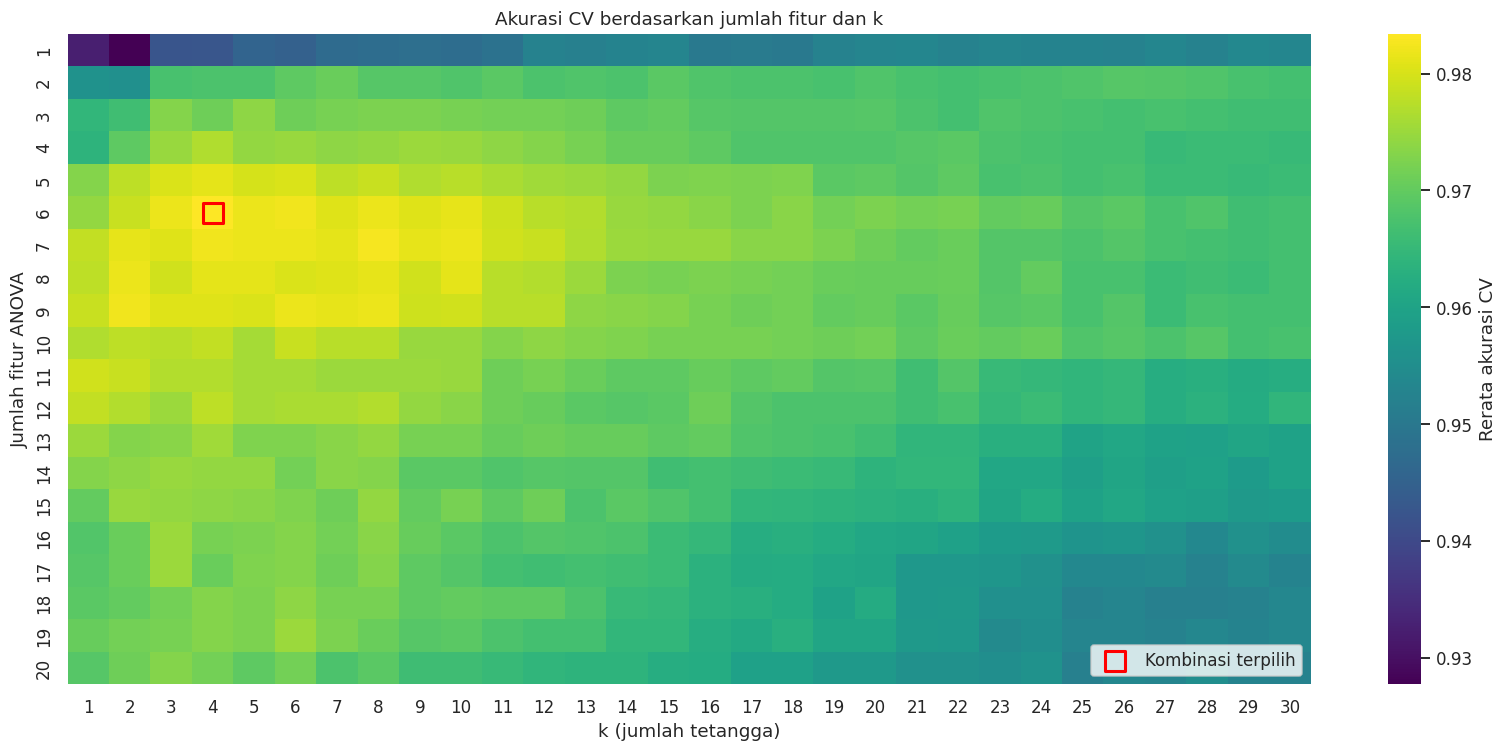

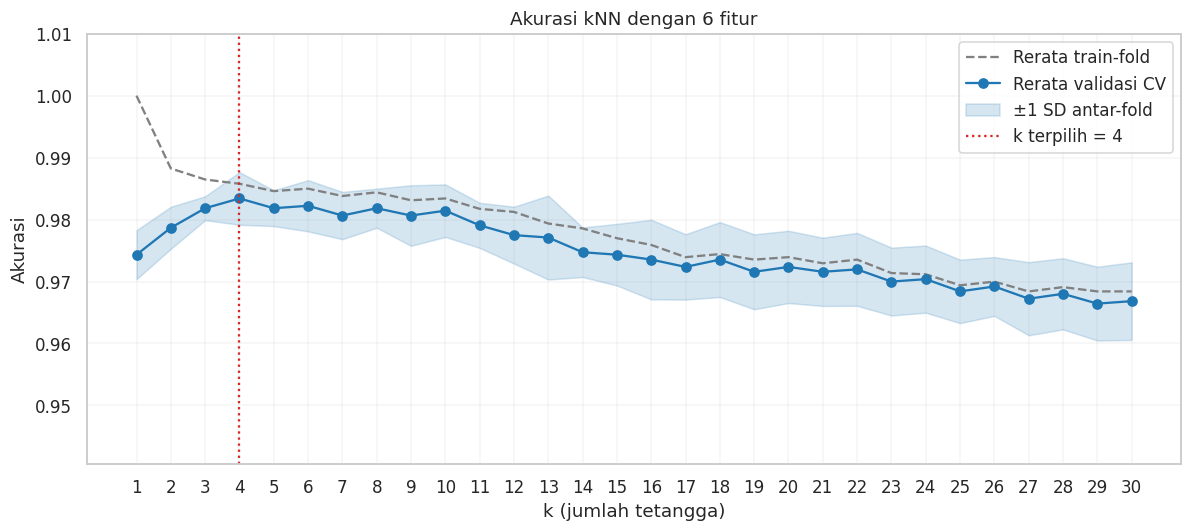

In [9]:
voice_heatmap = voice_results.pivot(index="jumlah_fitur", columns="k", values="mean_test_score")
voice_fig, voice_ax = plt.subplots(figsize=(15, 7))
sns.heatmap(voice_heatmap, ax=voice_ax, cmap="viridis", cbar_kws={"label": "Rerata akurasi CV"})
voice_ax.scatter(
    voice_heatmap.columns.get_loc(voice_best_k) + 0.5,
    voice_heatmap.index.get_loc(voice_best_features_count) + 0.5,
    marker="s", s=170, facecolors="none", edgecolors="red", linewidths=2, label="Kombinasi terpilih"
)
voice_ax.set(title="Akurasi CV berdasarkan jumlah fitur dan k", xlabel="k (jumlah tetangga)", ylabel="Jumlah fitur ANOVA")
voice_ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

voice_curve = voice_results.loc[voice_results["jumlah_fitur"].eq(voice_best_features_count)].sort_values("k")
voice_curve_k = voice_curve["k"].to_numpy(dtype=int)
voice_curve_mean = voice_curve["mean_test_score"].to_numpy(dtype=float)
voice_curve_sd = voice_curve["std_test_score"].to_numpy(dtype=float)
voice_fig, voice_ax = plt.subplots(figsize=(11, 5))
voice_ax.plot(voice_curve_k, voice_curve["mean_train_score"], "--", label="Rerata train-fold", color="gray")
voice_ax.plot(voice_curve_k, voice_curve_mean, "o-", label="Rerata validasi CV", color="tab:blue")
voice_ax.fill_between(voice_curve_k, np.maximum(0, voice_curve_mean - voice_curve_sd), np.minimum(1, voice_curve_mean + voice_curve_sd), alpha=0.18, color="tab:blue", label="±1 SD antar-fold")
voice_ax.axvline(voice_best_k, color="tab:red", linestyle=":", label=f"k terpilih = {voice_best_k}")
voice_ax.set(title=f"Akurasi kNN dengan {voice_best_features_count} fitur", xlabel="k (jumlah tetangga)", ylabel="Akurasi")
voice_ax.set_xticks(range(1, 31))
voice_ax.set_ylim(max(0, float((voice_curve_mean - voice_curve_sd).min()) - 0.02), 1.01)
voice_ax.legend()
voice_ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Fitur terpilih:
sd, Q25, IQR, sp.ent, sfm, meanfun


,Fitur,Skor F ANOVA,Dipilih
0,meanfun,5773.9847,True
1,IQR,1556.6630,True
2,Q25,880.8069,True
3,sp.ent,769.7663,True
4,sd,734.5347,True
5,sfm,353.8129,True
6,centroid,317.1296,False
7,meanfreq,317.1296,False
8,median,213.5933,False
9,mindom,97.4322,False


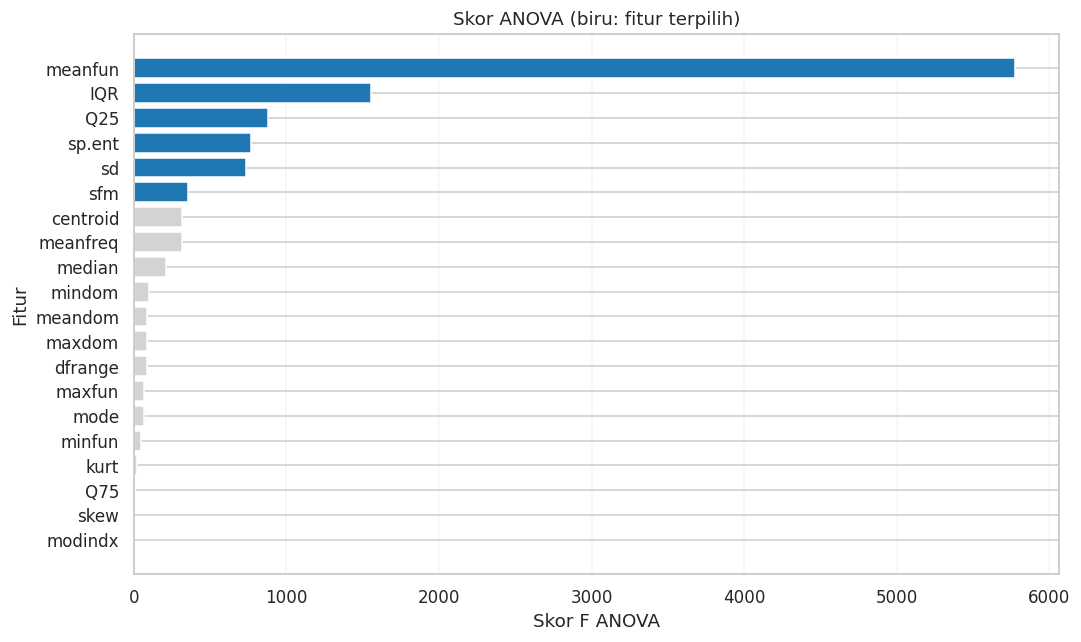

In [10]:
# Fitur dari model akhir.
voice_selector = voice_best_model.named_steps["select"]
voice_selected_features = voice_X_train.columns[voice_selector.get_support()].tolist()
voice_feature_scores = pd.DataFrame({
    "Fitur": voice_X_train.columns,
    "Skor F ANOVA": voice_selector.scores_,
    "Dipilih": voice_selector.get_support(),
}).sort_values("Skor F ANOVA", ascending=False)
print("Fitur terpilih:")
print(", ".join(voice_selected_features))
display(voice_feature_scores.reset_index(drop=True))

voice_fig, voice_ax = plt.subplots(figsize=(10, 6))
voice_feature_plot = voice_feature_scores.sort_values("Skor F ANOVA", ascending=True)
voice_ax.barh(voice_feature_plot["Fitur"], voice_feature_plot["Skor F ANOVA"], color=["tab:blue" if voice_selected else "lightgray" for voice_selected in voice_feature_plot["Dipilih"]])
voice_ax.set(title="Skor ANOVA (biru: fitur terpilih)", xlabel="Skor F ANOVA", ylabel="Fitur")
voice_ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

### Evaluasi

Model terpilih diuji pada data uji. Confusion matrix menunjukkan jumlah prediksi benar dan salah untuk tiap label.

,Akurasi train,Akurasi test,F1 makro,Balanced accuracy
Model,,,,
"Voice — kNN (6 fitur, k=4)",0.9858,0.9795,0.9795,0.9795


              precision    recall  f1-score   support

      female       0.97      0.99      0.98       317
        male       0.99      0.97      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



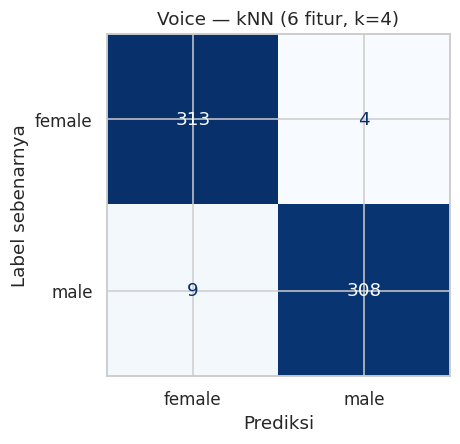

In [11]:
voice_final_metrics = evaluasi_model(
    voice_best_model, voice_X_train, voice_X_test, voice_y_train, voice_y_test,
    nama=f"Voice — kNN ({voice_best_features_count} fitur, k={voice_best_k})",
    labels=["female", "male"]
)

In [12]:
voice_feature_text = ", ".join(f"`{voice_name}`" for voice_name in voice_selected_features)
voice_tied = voice_results.loc[voice_results["mean_test_score"].eq(voice_best_cv)]
voice_tie_note = (
    "Jika skor sama, dipilih fitur lebih sedikit lalu k lebih besar."
    if len(voice_tied) > 1 else ""
)
display(Markdown(f"""
### Jawaban

1. **Model:** kNN dengan standardisasi dan seleksi fitur ANOVA. Akurasi data uji sebesar **{voice_final_metrics['Akurasi test']:.2%}**.
2. **Fitur:** terpilih **{voice_best_features_count} fitur**, yaitu {voice_feature_text}.
3. **Nilai k:** **{voice_best_k}**, karena kombinasi ini mendapat rata-rata akurasi CV tertinggi, yaitu **{voice_best_cv:.2%}**. {voice_tie_note}

Hasil terbaik ini berlaku untuk kandidat jumlah fitur dan k yang dicoba.
"""))


### Jawaban

1. **Model:** kNN dengan standardisasi dan seleksi fitur ANOVA. Akurasi data uji sebesar **97.95%**.
2. **Fitur:** terpilih **6 fitur**, yaitu `sd`, `Q25`, `IQR`, `sp.ent`, `sfm`, `meanfun`.
3. **Nilai k:** **4**, karena kombinasi ini mendapat rata-rata akurasi CV tertinggi, yaitu **98.34%**. 

Hasil terbaik ini berlaku untuk kandidat jumlah fitur dan k yang dicoba.
